# 📊 Stock Price Forecasting — Model Comparison
## LSTM vs N-BEATS

This notebook loads the trained LSTM and N-BEATS models from Google Drive
and runs a **side-by-side comparison** on the same test set.

### Prerequisites — run these first:
- `colab_lstm.ipynb` — must be complete, artefacts saved to Drive
- `colab_nbeats.ipynb` — must be complete, artefacts saved to Drive

### What this notebook produces:
1. Side-by-side forecast plot: LSTM vs N-BEATS vs actual prices
2. Combined metrics table: MAE, RMSE, MAPE, DA% — colour-coded (green = best)
3. Walk-forward backtest for both models on the same period
4. Combined equity curve: LSTM + N-BEATS + buy-and-hold on one chart
5. Combined backtest metrics table: Sharpe, Max Drawdown
6. Summary: which model won and why

**No retraining happens here. This notebook is inference + visualisation only.**

**Config must exactly match what was used during training.**

In [1]:
# Block 2 — Install dependencies + imports

!pip install -q yfinance ta torch scikit-learn joblib pandas numpy matplotlib
print("✅ Packages installed.")

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import yfinance as yf
import joblib

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import ta

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Imports complete. Device: {DEVICE}")

  Preparing metadata (setup.py) ... done
✅ Packages installed.
✅ Imports complete. Device: cuda


In [2]:
# Block 3 — Mount Google Drive

from google.colab import drive
drive.mount("/content/drive", force_remount=False)
print("✅ Google Drive mounted at /content/drive")

Mounted at /content/drive
✅ Google Drive mounted at /content/drive


In [3]:
# Block 4 — Configuration
# ── CRITICAL: must match training notebooks exactly ───────────────────

TICKER        = "AAPL"
START_DATE    = "2018-01-01"
END_DATE      = "2024-12-31"
HORIZON       = 7
WINDOW        = 60

TRAIN_FRAC    = 0.70
VAL_FRAC      = 0.15

# N-BEATS architecture params — needed to reconstruct the model class
NBEATS_BLOCKS  = 3
NBEATS_HIDDEN  = 256
NBEATS_LAYERS  = 4

# LSTM architecture params — needed to reconstruct the model class
LSTM_HIDDEN    = 128
LSTM_LAYERS    = 2
LSTM_DROPOUT   = 0.2

# ── Google Drive paths ────────────────────────────────────────────────
DRIVE_DIR   = "/content/drive/MyDrive/stock_forecasting"
DATA_DIR    = os.path.join(DRIVE_DIR, "data")
MODEL_DIR   = os.path.join(DRIVE_DIR, "models")
RESULTS_DIR = os.path.join(DRIVE_DIR, "results")

os.makedirs(RESULTS_DIR, exist_ok=True)

# Verify all artefacts exist before proceeding
required_files = [
    os.path.join(MODEL_DIR, "lstm_best.pt"),
    os.path.join(MODEL_DIR, "lstm_scaler.joblib"),
    os.path.join(MODEL_DIR, "nbeats_best.pt"),
    os.path.join(MODEL_DIR, "nbeats_scaler.joblib"),
]
for f in required_files:
    status = "✅" if os.path.exists(f) else "❌ MISSING"
    print(f"  {status}  {f}")

print(f"\n✅ Config set | Ticker: {TICKER} | Horizon: {HORIZON}d | Window: {WINDOW}d")

  ✅  /content/drive/MyDrive/stock_forecasting/models/lstm_best.pt
  ✅  /content/drive/MyDrive/stock_forecasting/models/lstm_scaler.joblib
  ✅  /content/drive/MyDrive/stock_forecasting/models/nbeats_best.pt
  ✅  /content/drive/MyDrive/stock_forecasting/models/nbeats_scaler.joblib

✅ Config set | Ticker: AAPL | Horizon: 7d | Window: 60d


In [5]:
# Block 5 — Fetch + engineer features (same pipeline, no training)

# ── Fetch ─────────────────────────────────────────────────────────────
CACHE_PATH = os.path.join(DATA_DIR, f"{TICKER}_ohlcv.csv")

if os.path.exists(CACHE_PATH):
    print(f"📂 Loading cached data: {CACHE_PATH}")
    try:
        df_raw = pd.read_csv(CACHE_PATH, skiprows=[1, 2], index_col=0)
        df_raw.index = pd.to_datetime(df_raw.index)
        df_raw.index.name = "Date"

        if not all(c in df_raw.columns for c in ["Open", "High", "Low", "Close", "Volume"]):
            raise ValueError(f"Missing expected columns. Got: {df_raw.columns.tolist()}")

        print(f"✅ Cache loaded. Columns: {df_raw.columns.tolist()}")

    except Exception as e:
        print(f"⚠️  Cache malformed ({e}). Re-downloading ...")
        df_raw = yf.download(TICKER, start=START_DATE, end=END_DATE, auto_adjust=True)
        if isinstance(df_raw.columns, pd.MultiIndex):
            df_raw.columns = df_raw.columns.get_level_values(0)
        df_raw.index.name = "Date"
        df_raw.to_csv(CACHE_PATH)
        print(f"💾 Cache overwritten → {CACHE_PATH}")

else:
    print(f"⬇️  Downloading {TICKER} ...")
    df_raw = yf.download(TICKER, start=START_DATE, end=END_DATE, auto_adjust=True)
    if isinstance(df_raw.columns, pd.MultiIndex):
        df_raw.columns = df_raw.columns.get_level_values(0)
    df_raw.index.name = "Date"
    df_raw.to_csv(CACHE_PATH)
    print(f"💾 Saved to {CACHE_PATH}")

df_raw = df_raw[["Open", "High", "Low", "Close", "Volume"]].copy()
df_raw.dropna(inplace=True)

# ── Feature engineering ───────────────────────────────────────────────
df = df_raw.copy()
close, high, low, vol = df["Close"], df["High"], df["Low"], df["Volume"]

df["EMA_20"]   = ta.trend.EMAIndicator(close, window=20).ema_indicator()
df["EMA_50"]   = ta.trend.EMAIndicator(close, window=50).ema_indicator()
macd_obj       = ta.trend.MACD(close)
df["MACD"]     = macd_obj.macd()
df["MACD_sig"] = macd_obj.macd_signal()
df["ADX"]      = ta.trend.ADXIndicator(high, low, close, window=14).adx()
df["RSI"]      = ta.momentum.RSIIndicator(close, window=14).rsi()
df["Stoch_K"]  = ta.momentum.StochasticOscillator(high, low, close).stoch()
bb             = ta.volatility.BollingerBands(close, window=20)
df["BB_high"]  = bb.bollinger_hband()
df["BB_low"]   = bb.bollinger_lband()
df["ATR"]      = ta.volatility.AverageTrueRange(high, low, close, window=14).average_true_range()
df["OBV"]      = ta.volume.OnBalanceVolumeIndicator(close, vol).on_balance_volume()
df["VWAP"]     = ta.volume.VolumeWeightedAveragePrice(high, low, close, vol).volume_weighted_average_price()

df.dropna(inplace=True)
assert df.isna().sum().sum() == 0

# ── Temporal split ────────────────────────────────────────────────────
n         = len(df)
train_end = int(n * TRAIN_FRAC)
val_end   = int(n * (TRAIN_FRAC + VAL_FRAC))

df_train  = df.iloc[:train_end]
df_val    = df.iloc[train_end:val_end]
df_test   = df.iloc[val_end:]

# ── Column metadata ───────────────────────────────────────────────────
FEATURE_COLS = [c for c in df.columns if c != "Close"]
TARGET_COL   = "Close"
ALL_COLS     = FEATURE_COLS + [TARGET_COL]
CLOSE_IDX    = ALL_COLS.index(TARGET_COL)
N_FEATURES   = len(ALL_COLS)
INPUT_SIZE   = WINDOW * N_FEATURES

print(f"✅ Data pipeline complete")
print(f"   Shape: {df.shape} | Test rows: {len(df_test)}")
print(f"   Test period: {df_test.index[0].date()} → {df_test.index[-1].date()}")
print(f"   n_features: {N_FEATURES} | flat input size (N-BEATS): {INPUT_SIZE}")

📂 Loading cached data: /content/drive/MyDrive/stock_forecasting/data/AAPL_ohlcv.csv
✅ Cache loaded. Columns: ['Close', 'High', 'Low', 'Open', 'Volume']
✅ Data pipeline complete
   Shape: (1711, 17) | Test rows: 257
   Test period: 2023-12-21 → 2024-12-30
   n_features: 17 | flat input size (N-BEATS): 1020


In [6]:
# Block 6 — Load LSTM model + scaler from Drive

# ── Model class (must match colab_lstm.ipynb Block 13) ────────────────
class LSTMForecaster(nn.Module):
    def __init__(self, n_features, hidden, n_layers, dropout, horizon):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features, hidden_size=hidden,
            num_layers=n_layers, dropout=dropout if n_layers > 1 else 0.0,
            batch_first=True, bidirectional=True
        )
        self.head = nn.Sequential(
            nn.Linear(hidden * 2, 64), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, horizon)
        )
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :])

# ── Instantiate + load weights ─────────────────────────────────────────
lstm_model = LSTMForecaster(
    n_features=N_FEATURES,
    hidden=LSTM_HIDDEN,
    n_layers=LSTM_LAYERS,
    dropout=LSTM_DROPOUT,
    horizon=HORIZON
).to(DEVICE)

lstm_model.load_state_dict(
    torch.load(os.path.join(MODEL_DIR, "lstm_best.pt"), map_location=DEVICE)
)
lstm_model.eval()

# ── Load scaler ────────────────────────────────────────────────────────
lstm_scaler = joblib.load(os.path.join(MODEL_DIR, "lstm_scaler.joblib"))

print("✅ LSTM model loaded and set to eval mode")
print(f"   Scaler feature range: {lstm_scaler.feature_range}")

✅ LSTM model loaded and set to eval mode
   Scaler feature range: (0, 1)


In [7]:
# Block 7 — Load N-BEATS model + scaler from Drive

# ── Model classes (must match colab_nbeats.ipynb Blocks 13–14) ────────
class NBeatsBlock(nn.Module):
    def __init__(self, input_size, hidden_size, n_layers, horizon):
        super().__init__()
        fc_layers = []
        in_dim = input_size
        for _ in range(n_layers):
            fc_layers += [nn.Linear(in_dim, hidden_size), nn.ReLU()]
            in_dim = hidden_size
        self.fc_stack      = nn.Sequential(*fc_layers)
        self.backcast_head = nn.Linear(hidden_size, input_size)
        self.forecast_head = nn.Linear(hidden_size, horizon)

    def forward(self, x):
        h = self.fc_stack(x)
        return self.backcast_head(h), self.forecast_head(h)


class NBeats(nn.Module):
    def __init__(self, input_size, hidden_size, n_layers, n_blocks, horizon):
        super().__init__()
        self.blocks = nn.ModuleList([
            NBeatsBlock(input_size, hidden_size, n_layers, horizon)
            for _ in range(n_blocks)
        ])

    def forward(self, x):
        residual       = x
        total_forecast = torch.zeros(x.size(0), self.blocks[0].forecast_head.out_features,
                                     device=x.device)
        for block in self.blocks:
            backcast, forecast = block(residual)
            residual           = residual - backcast
            total_forecast     = total_forecast + forecast
        return total_forecast


# ── Instantiate + load weights ─────────────────────────────────────────
nbeats_model = NBeats(
    input_size=INPUT_SIZE,
    hidden_size=NBEATS_HIDDEN,
    n_layers=NBEATS_LAYERS,
    n_blocks=NBEATS_BLOCKS,
    horizon=HORIZON
).to(DEVICE)

nbeats_model.load_state_dict(
    torch.load(os.path.join(MODEL_DIR, "nbeats_best.pt"), map_location=DEVICE)
)
nbeats_model.eval()

# ── Load scaler ────────────────────────────────────────────────────────
nbeats_scaler = joblib.load(os.path.join(MODEL_DIR, "nbeats_scaler.joblib"))

print("✅ N-BEATS model loaded and set to eval mode")
print(f"   Scaler feature range: {nbeats_scaler.feature_range}")

✅ N-BEATS model loaded and set to eval mode
   Scaler feature range: (0, 1)


In [8]:
# Block 8 — Run inference with both models on the same test set

def run_inference(model, scaler, is_flat: bool):
    """
    Scales df_test with the given scaler, builds Dataset, runs inference,
    and inverse-scales predictions and actuals back to price units.

    is_flat=True  → N-BEATS (flatten input)
    is_flat=False → LSTM    (keep sequence shape)
    """
    # Scale using this model's own scaler
    train_sc = scaler.transform(df_train[ALL_COLS])
    test_sc  = scaler.transform(df_test[ALL_COLS])

    # Build sliding window samples manually (avoids redefining Dataset classes)
    X_list, y_list = [], []
    for i in range(len(test_sc) - WINDOW - HORIZON + 1):
        x = test_sc[i : i + WINDOW, :]                          # (W, F)
        y = test_sc[i + WINDOW : i + WINDOW + HORIZON, CLOSE_IDX]  # (H,)
        if is_flat:
            X_list.append(x.flatten())   # (W*F,)
        else:
            X_list.append(x)             # (W, F)
        y_list.append(y)

    X = torch.tensor(np.array(X_list), dtype=torch.float32).to(DEVICE)
    y = np.array(y_list)   # (n_samples, horizon) — scaled actuals

    # Forward pass in batches
    preds_list = []
    BATCH = 64
    model.eval()
    with torch.no_grad():
        for i in range(0, len(X), BATCH):
            preds_list.append(model(X[i:i+BATCH]).cpu().numpy())
    preds_scaled = np.concatenate(preds_list, axis=0)   # (n_samples, horizon)

    # Inverse-scale helper
    n_cols = len(ALL_COLS)
    def inv(arr):
        n, h = arr.shape
        buf = np.zeros((n * h, n_cols))
        buf[:, CLOSE_IDX] = arr.reshape(-1)
        return scaler.inverse_transform(buf)[:, CLOSE_IDX].reshape(n, h)

    return inv(preds_scaled), inv(y)


lstm_preds,   lstm_actuals   = run_inference(lstm_model,   lstm_scaler,   is_flat=False)
nbeats_preds, nbeats_actuals = run_inference(nbeats_model, nbeats_scaler, is_flat=True)

# Day-1 of horizon for all plots and metrics
lstm_pred1   = lstm_preds[:, 0]
nbeats_pred1 = nbeats_preds[:, 0]
actual_day1  = lstm_actuals[:, 0]   # same for both — use LSTM actuals as reference

test_dates = df_test.index[WINDOW : WINDOW + len(actual_day1)]

print(f"✅ Inference complete")
print(f"   Samples: {len(actual_day1)} | Test period: {test_dates[0].date()} → {test_dates[-1].date()}")
print(f"   LSTM preds range:   [{lstm_pred1.min():.2f}, {lstm_pred1.max():.2f}]")
print(f"   N-BEATS preds range:[{nbeats_pred1.min():.2f}, {nbeats_pred1.max():.2f}]")
print(f"   Actual range:       [{actual_day1.min():.2f}, {actual_day1.max():.2f}]")

✅ Inference complete
   Samples: 191 | Test period: 2024-03-20 → 2024-12-19
   LSTM preds range:   [164.01, 203.48]
   N-BEATS preds range:[180.01, 239.87]
   Actual range:       [163.36, 251.87]


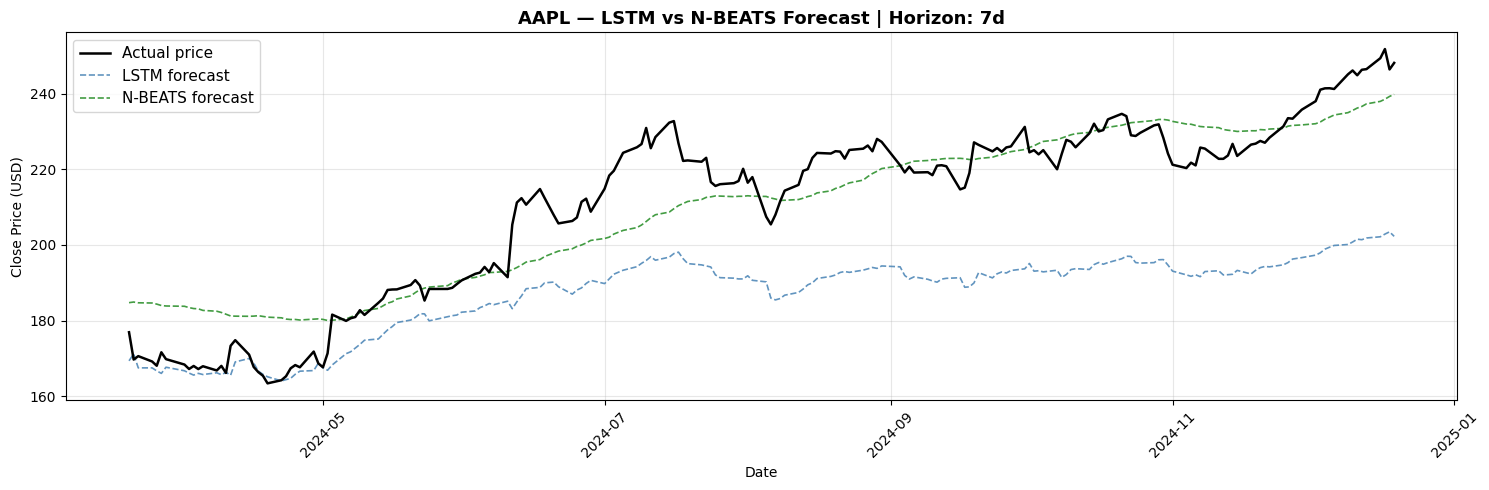

✅ Side-by-side forecast plot complete


In [9]:
# Block 9 — Side-by-side forecast plot (LSTM vs N-BEATS vs actual)

fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(test_dates, actual_day1,  color="black",       linewidth=1.8, label="Actual price",    zorder=3)
ax.plot(test_dates, lstm_pred1,   color="steelblue",   linewidth=1.2, linestyle="--",
        label="LSTM forecast",    alpha=0.85)
ax.plot(test_dates, nbeats_pred1, color="forestgreen", linewidth=1.2, linestyle="--",
        label="N-BEATS forecast", alpha=0.85)

ax.set_title(f"{TICKER} — LSTM vs N-BEATS Forecast | Horizon: {HORIZON}d",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Close Price (USD)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("✅ Side-by-side forecast plot complete")

In [10]:
# Block 10 — Combined metrics table (colour-coded with pandas Styler)

def compute_metrics(y_true, y_pred, label):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.abs(y_true))) * 100
    # Directional accuracy vs previous actual close
    prev = df_test["Close"].values[WINDOW - 1 : WINDOW - 1 + len(y_true)]
    da   = np.mean(np.sign(y_pred - prev) == np.sign(y_true - prev)) * 100
    return {"Model": label, "MAE": round(mae, 4), "RMSE": round(rmse, 4),
            "MAPE (%)": round(mape, 4), "DA (%)": round(da, 2)}

lstm_m   = compute_metrics(actual_day1, lstm_pred1,   "LSTM")
nbeats_m = compute_metrics(actual_day1, nbeats_pred1, "N-BEATS")

metrics_df = pd.DataFrame([lstm_m, nbeats_m]).set_index("Model")

# ── Colour coding: green = best, red = worst per column ───────────────
def highlight_best(col):
    """Green = best value, red = worst. Direction depends on metric."""
    higher_is_better = col.name == "DA (%)"
    colours = [""] * len(col)
    best_idx  = col.idxmax() if higher_is_better else col.idxmin()
    worst_idx = col.idxmin() if higher_is_better else col.idxmax()
    colours[col.index.get_loc(best_idx)]  = "background-color: #d4edda; color: #155724"
    colours[col.index.get_loc(worst_idx)] = "background-color: #f8d7da; color: #721c24"
    return colours

styled = (
    metrics_df.style
    .apply(highlight_best, axis=0)
    .format(precision=4)
    .set_caption(f"{TICKER} — LSTM vs N-BEATS | Test Set Metrics (Day-1 Forecast, Horizon={HORIZON}d)")
)

# Save raw CSV
comp_path = os.path.join(RESULTS_DIR, "comparison_metrics.csv")
metrics_df.to_csv(comp_path)

print(f"✅ Combined metrics table:\n")
display(styled)
print(f"\n💾 Saved → {comp_path}")

✅ Combined metrics table:



,MAE,RMSE,MAPE (%),DA (%)
Model,,,,
LSTM,23.6577,27.1626,10.6181,39.2700
N-BEATS,7.4764,9.4883,3.6772,48.6900



💾 Saved → /content/drive/MyDrive/stock_forecasting/results/comparison_metrics.csv


In [11]:
# Block 11 — Walk-forward backtest for both models

actual_close = df_test["Close"].values
n_bt         = len(actual_day1)

actual_bt   = actual_close[WINDOW     : WINDOW + n_bt]
actual_next = actual_close[WINDOW + 1 : WINDOW + n_bt + 1]
bt_dates    = df_test.index[WINDOW : WINDOW + n_bt]

TC = 0.001   # 0.1% transaction cost per trade

def backtest(pred, label):
    signal        = (pred > actual_bt).astype(float)
    raw_returns   = (actual_next - actual_bt) / actual_bt
    strat_returns = signal * raw_returns
    pos_change    = np.abs(np.diff(signal, prepend=0.0))
    strat_returns -= pos_change * TC
    equity        = np.cumprod(1 + strat_returns)
    n_trades      = int(pos_change.sum())
    return strat_returns, equity, n_trades

bah_returns = (actual_next - actual_bt) / actual_bt
bah_equity  = np.cumprod(1 + bah_returns)

lstm_returns,   lstm_equity,   lstm_trades   = backtest(lstm_pred1,   "LSTM")
nbeats_returns, nbeats_equity, nbeats_trades = backtest(nbeats_pred1, "N-BEATS")

print(f"✅ Backtests complete | Period: {bt_dates[0].date()} → {bt_dates[-1].date()}")
print(f"   LSTM   trades: {lstm_trades}   | Final equity: {lstm_equity[-1]:.4f}")
print(f"   N-BEATS trades: {nbeats_trades} | Final equity: {nbeats_equity[-1]:.4f}")
print(f"   Buy & hold final equity: {bah_equity[-1]:.4f}")

✅ Backtests complete | Period: 2024-03-20 → 2024-12-19
   LSTM   trades: 8   | Final equity: 1.0126
   N-BEATS trades: 20 | Final equity: 1.3133
   Buy & hold final equity: 1.4295


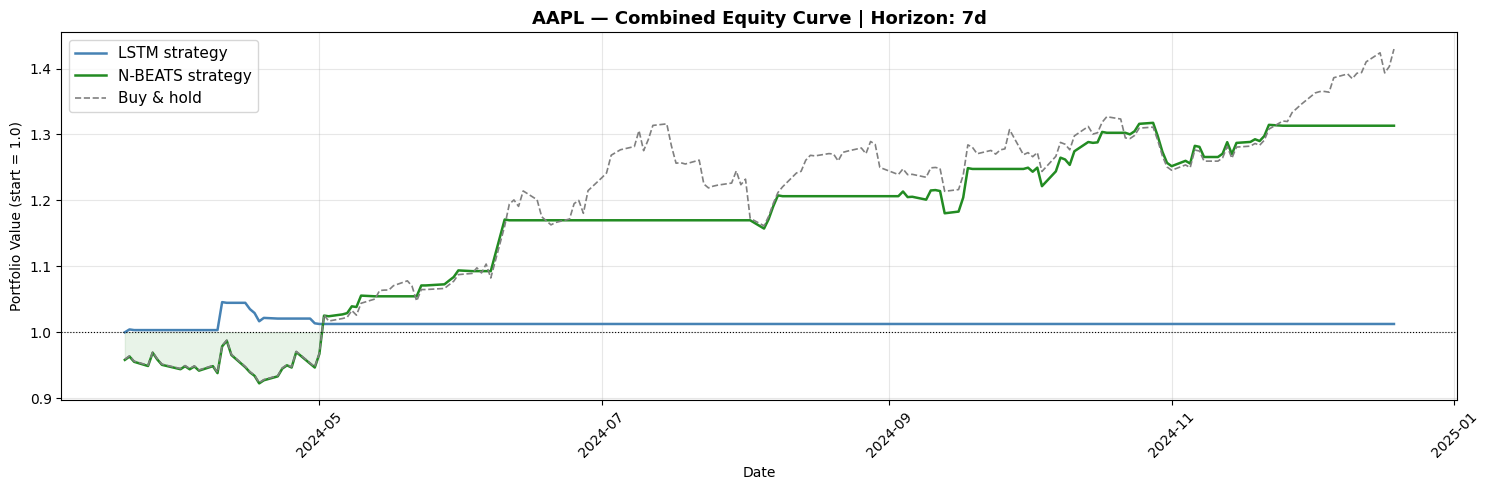

✅ Combined equity curve plotted


In [12]:
# Block 12 — Combined equity curve (LSTM + N-BEATS + buy-and-hold)

fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(bt_dates, lstm_equity,   color="steelblue",   linewidth=1.8, label="LSTM strategy")
ax.plot(bt_dates, nbeats_equity, color="forestgreen", linewidth=1.8, label="N-BEATS strategy")
ax.plot(bt_dates, bah_equity,    color="grey",        linewidth=1.2, linestyle="--",
        label="Buy & hold")
ax.axhline(y=1.0, color="black", linewidth=0.8, linestyle=":")

# Shade loss zones for each model
ax.fill_between(bt_dates, lstm_equity, 1.0,
                where=(lstm_equity < 1.0), alpha=0.10, color="steelblue")
ax.fill_between(bt_dates, nbeats_equity, 1.0,
                where=(nbeats_equity < 1.0), alpha=0.10, color="forestgreen")

ax.set_title(f"{TICKER} — Combined Equity Curve | Horizon: {HORIZON}d",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Portfolio Value (start = 1.0)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("✅ Combined equity curve plotted")

In [13]:
# Block 13 — Combined backtest metrics table

def backtest_metrics(returns, equity, label):
    sharpe = (np.mean(returns) / (np.std(returns) + 1e-9)) * np.sqrt(252)
    peak   = np.maximum.accumulate(equity)
    max_dd = ((equity - peak) / peak).min() * 100
    return {"Model": label, "Sharpe Ratio": round(sharpe, 4),
            "Max Drawdown (%)": round(max_dd, 2),
            "Final Equity":     round(equity[-1], 4)}

bah_sharpe = (np.mean(bah_returns) / (np.std(bah_returns) + 1e-9)) * np.sqrt(252)
bah_peak   = np.maximum.accumulate(bah_equity)
bah_max_dd = ((bah_equity - bah_peak) / bah_peak).min() * 100

bt_df = pd.DataFrame([
    backtest_metrics(lstm_returns,   lstm_equity,   "LSTM"),
    backtest_metrics(nbeats_returns, nbeats_equity, "N-BEATS"),
    {"Model": "Buy & Hold", "Sharpe Ratio": round(bah_sharpe, 4),
     "Max Drawdown (%)": round(bah_max_dd, 2), "Final Equity": round(bah_equity[-1], 4)}
]).set_index("Model")

def highlight_best_bt(col):
    # Sharpe + Final Equity: higher = better. Max Drawdown: less negative = better (higher)
    colours = [""] * len(col)
    best_idx  = col.idxmax()
    worst_idx = col.idxmin() if col.name != "Max Drawdown (%)" else col.idxmin()
    colours[col.index.get_loc(best_idx)]  = "background-color: #d4edda; color: #155724"
    colours[col.index.get_loc(worst_idx)] = "background-color: #f8d7da; color: #721c24"
    return colours

styled_bt = (
    bt_df.style
    .apply(highlight_best_bt, axis=0)
    .format(precision=4)
    .set_caption(f"{TICKER} — Backtest Metrics | Horizon: {HORIZON}d")
)

print("✅ Combined backtest metrics:\n")
display(styled_bt)

✅ Combined backtest metrics:



,Sharpe Ratio,Max Drawdown (%),Final Equity
Model,,,
LSTM,0.3357,-3.1700,1.0126
N-BEATS,2.1001,-6.5400,1.3133
Buy & Hold,2.1231,-11.7500,1.4295


In [14]:
# Block 14 — Auto-generated summary: which model won and why

print("=" * 60)
print(f"  SUMMARY — {TICKER} | Horizon: {HORIZON}d")
print("=" * 60)

# Forecast metrics winner
mae_winner    = metrics_df["MAE"].idxmin()
rmse_winner   = metrics_df["RMSE"].idxmin()
mape_winner   = metrics_df["MAPE (%)"].idxmin()
da_winner     = metrics_df["DA (%)"].idxmax()

print(f"\n📐 Forecast Accuracy (test set, day-1):")
print(f"   MAE  winner → {mae_winner}   ({metrics_df.loc[mae_winner, 'MAE']:.4f})")
print(f"   RMSE winner → {rmse_winner}  ({metrics_df.loc[rmse_winner, 'RMSE']:.4f})")
print(f"   MAPE winner → {mape_winner}  ({metrics_df.loc[mape_winner, 'MAPE (%)']:.4f}%)")
print(f"   DA%  winner → {da_winner}    ({metrics_df.loc[da_winner, 'DA (%)']:.2f}%)")

# Count wins
wins = {"LSTM": 0, "N-BEATS": 0}
for w in [mae_winner, rmse_winner, mape_winner, da_winner]:
    if w in wins:
        wins[w] += 1

forecast_winner = max(wins, key=wins.get)
print(f"\n   📊 Forecast winner: {forecast_winner} ({wins[forecast_winner]}/4 metrics)")

# Backtest winner
sharpe_winner = bt_df["Sharpe Ratio"].drop("Buy & Hold").idxmax()
dd_winner     = bt_df["Max Drawdown (%)"].drop("Buy & Hold").idxmax()  # least negative = best
eq_winner     = bt_df["Final Equity"].drop("Buy & Hold").idxmax()

print(f"\n📈 Backtest Performance:")
print(f"   Sharpe winner      → {sharpe_winner}  ({bt_df.loc[sharpe_winner, 'Sharpe Ratio']:.4f})")
print(f"   Max DD winner      → {dd_winner}      ({bt_df.loc[dd_winner, 'Max Drawdown (%)']:.2f}%)")
print(f"   Final equity winner→ {eq_winner}      ({bt_df.loc[eq_winner, 'Final Equity']:.4f})")

bt_wins = {"LSTM": 0, "N-BEATS": 0}
for w in [sharpe_winner, dd_winner, eq_winner]:
    if w in bt_wins:
        bt_wins[w] += 1

backtest_winner = max(bt_wins, key=bt_wins.get)
print(f"\n   📊 Backtest winner: {backtest_winner} ({bt_wins[backtest_winner]}/3 metrics)")

# Overall
print(f"\n{'=' * 60}")
overall_wins = {
    "LSTM":    wins["LSTM"]    + bt_wins["LSTM"],
    "N-BEATS": wins["N-BEATS"] + bt_wins["N-BEATS"]
}
overall_winner = max(overall_wins, key=overall_wins.get)
print(f"  🏆 OVERALL WINNER: {overall_winner} "
      f"({overall_wins[overall_winner]}/7 metrics won)")
print(f"{'=' * 60}")

# Practical note on DA%
lstm_da   = metrics_df.loc["LSTM",    "DA (%)"]
nbeats_da = metrics_df.loc["N-BEATS", "DA (%)"]
print(f"\n💡 Directional Accuracy note:")
print(f"   LSTM: {lstm_da:.2f}%  |  N-BEATS: {nbeats_da:.2f}%")
print(f"   A random baseline scores ~50%. Above 55% is generally considered useful.")
if max(lstm_da, nbeats_da) < 52:
    print(f"   ⚠️  Both models are near random — consider tuning features or horizon.")

  SUMMARY — AAPL | Horizon: 7d

📐 Forecast Accuracy (test set, day-1):
   MAE  winner → N-BEATS   (7.4764)
   RMSE winner → N-BEATS  (9.4883)
   MAPE winner → N-BEATS  (3.6772%)
   DA%  winner → N-BEATS    (48.69%)

   📊 Forecast winner: N-BEATS (4/4 metrics)

📈 Backtest Performance:
   Sharpe winner      → N-BEATS  (2.1001)
   Max DD winner      → LSTM      (-3.17%)
   Final equity winner→ N-BEATS      (1.3133)

   📊 Backtest winner: N-BEATS (2/3 metrics)

  🏆 OVERALL WINNER: N-BEATS (6/7 metrics won)

💡 Directional Accuracy note:
   LSTM: 39.27%  |  N-BEATS: 48.69%
   A random baseline scores ~50%. Above 55% is generally considered useful.
   ⚠️  Both models are near random — consider tuning features or horizon.
